# Fingerprint Embedding Network — POC
# Run all cells top-to-bottom.  Requires torch, numpy, scikit-learn, matplotlib.


In [16]:
import os, sys, random, math
from collections import defaultdict
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.optim import SGD
from torch.optim.lr_scheduler import CosineAnnealingLR
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

# ── Paths ─────────────────────────────────────────────────────────────────────
_here      = os.path.dirname(os.path.abspath("__file__"))
REPO_ROOT  = os.path.abspath(os.path.join(_here, "..", ".."))
sys.path.insert(0, REPO_ROOT)
_be_dir    = os.path.join(REPO_ROOT, "training", "be_ann_w_fingerprints")
DEV_NPZ    = os.path.join(_be_dir, "dev_fingerprints.npz")
TEST_NPZ   = os.path.join(_be_dir, "test_fingerprints.npz")
CHECKPOINT = os.path.join(_be_dir, "best_model.pth")

# ── Hyperparameters ───────────────────────────────────────────────────────────
DEVICE       = torch.device("cpu")
EMBED_DIM    = 256
NUM_CLASSES  = 100
M            = 0.2    # AAM-Softmax margin
S            = 16     # AAM-Softmax scale
LR           = 0.1
WEIGHT_DECAY = 5e-4
EPOCHS       = 80
P_CLASSES    = 10     # classes per PK batch
K_SAMPLES    = 3      # samples per class → batch size = 30

torch.manual_seed(42)
np.random.seed(42)
random.seed(42)
print("Config OK — REPO_ROOT:", REPO_ROOT)


Config OK — REPO_ROOT: /home/qphulong/workspace/snn_playground


In [ ]:
R_DENSE = 128

def build_dense(fp):
    """(672, 672) float32 → (257, 672): unroll diagonal, then z-score per hidden neuron.

    Row k, column j  =  weight from input (j - R_DENSE + k) % 672  to hidden j.
    Each column is z-scored independently (zero-mean, unit-std per hidden neuron).
    """
    N = fp.shape[1]
    offsets = np.arange(-R_DENSE, R_DENSE + 1)            # (257,)
    j_idx   = np.arange(N)                                # (672,)
    i_idx   = (j_idx[:, None] + offsets[None, :]) % N    # (672, 257) input indices
    dense   = fp[i_idx, j_idx[:, None]].T                # (257, 672)
    eps     = 1e-8
    mu      = dense.mean(axis=0, keepdims=True)           # (1, 672)
    std     = dense.std(axis=0, keepdims=True)            # (1, 672)
    return (dense - mu) / (std + eps)                    # (257, 672) z-scored

def load_split(npz_path):
    d    = np.load(npz_path, allow_pickle=True)
    fps  = d["fingerprints"].astype(np.float32)           # (N, 672, 672)
    dense = np.stack([build_dense(f) for f in fps])       # (N, 257, 672)
    fp   = dense[:, np.newaxis, :, :]                     # (N, 1, 257, 672)
    return fp, d["person_ids"], d["record_ids"]

X_train, pid_train, _ = load_split(DEV_NPZ)
X_val,   pid_val,   _ = load_split(TEST_NPZ)

all_persons     = sorted(set(pid_train.tolist()))
person_to_label = {p: i for i, p in enumerate(all_persons)}
y_train = np.array([person_to_label[p] for p in pid_train], dtype=np.int64)
y_val   = np.array([person_to_label[p] for p in pid_val],   dtype=np.int64)

print(f"Train : {X_train.shape}   mean={X_train.mean():.4f}  std={X_train.std():.4f}")
print(f"Val   : {X_val.shape}     mean={X_val.mean():.4f}  std={X_val.std():.4f}")
print(f"per-class counts train: {np.bincount(y_train).tolist()}")
print("Label map:", person_to_label)

In [18]:
class FingerprintAugment:
    """Online augmentation — applied per sample during training."""
    def __call__(self, x: torch.Tensor) -> torch.Tensor:
        x = x.clone().float()

        # Random W-crop: extract window, zero-pad back to 672
        crop_w = random.randint(576, 672)
        start  = random.randint(0, 672 - crop_w)
        x      = F.pad(x[:, :, start:start + crop_w], (0, 672 - crop_w))

        # Additive Gaussian noise with p=0.5
        if random.random() < 0.5:
            x = x + torch.randn_like(x) * (0.01 * x.std().item())

        # Random amplitude scale with p=0.5
        if random.random() < 0.5:
            x = x * random.uniform(0.95, 1.05)

        return x

In [19]:
class FingerprintDataset(Dataset):
    def __init__(self, X, y, augment=False):
        self.X   = torch.from_numpy(X)
        self.y   = torch.from_numpy(y).long()
        self.aug = FingerprintAugment() if augment else None

    def __len__(self):  return len(self.y)

    def __getitem__(self, idx):
        x = self.X[idx]
        if self.aug is not None:
            x = self.aug(x)
        return x, self.y[idx]


class PKBatchSampler:
    """Yields batches with exactly K samples from each of P randomly chosen classes."""
    def __init__(self, labels, P, K):
        self.K   = K
        arr      = np.asarray(labels)
        self.cls_idx = defaultdict(list)
        for i, l in enumerate(arr):
            self.cls_idx[int(l)].append(i)
        self.classes   = sorted(self.cls_idx.keys())
        self.P         = min(P, len(self.classes))
        self.n_batches = max(1, len(arr) // (self.P * K))

    def __iter__(self):
        for _ in range(self.n_batches):
            batch = []
            sampled_classes = np.random.choice(self.classes, self.P, replace=False)
            for c in sampled_classes:
                idx = self.cls_idx[c]
                chosen = np.random.choice(idx, self.K,
                                          replace=(len(idx) < self.K))
                batch.extend(chosen.tolist())
            yield batch

    def __len__(self): return self.n_batches


train_ds   = FingerprintDataset(X_train, y_train, augment=True)
val_ds     = FingerprintDataset(X_val,   y_val,   augment=False)
train_ds_eval = FingerprintDataset(X_train, y_train, augment=False)

train_loader      = DataLoader(train_ds, batch_sampler=PKBatchSampler(y_train, P_CLASSES, K_SAMPLES), num_workers=0)
train_loader_eval = DataLoader(train_ds_eval, batch_size=16, shuffle=False, num_workers=0)
val_loader        = DataLoader(val_ds,   batch_size=16, shuffle=False, num_workers=0)

print(f"Train batches/epoch : {len(train_loader)}")
print(f"Effective P         : {PKBatchSampler(y_train, P_CLASSES, K_SAMPLES).P}  (capped to available classes)")

Train batches/epoch : 1
Effective P         : 1  (capped to available classes)


In [20]:
class ResBlock(nn.Module):
    def __init__(self, in_ch, out_ch, stride=(1, 1)):
        super().__init__()
        s = stride if isinstance(stride, tuple) else (stride, stride)
        self.conv1    = nn.Conv2d(in_ch,  out_ch, 3, stride=s, padding=1, bias=False)
        self.bn1      = nn.BatchNorm2d(out_ch)
        self.act1     = nn.PReLU(out_ch)
        self.conv2    = nn.Conv2d(out_ch, out_ch, 3, stride=1, padding=1, bias=False)
        self.bn2      = nn.BatchNorm2d(out_ch)
        self.act2     = nn.PReLU(out_ch)
        self.shortcut = (
            nn.Sequential(nn.Conv2d(in_ch, out_ch, 1, stride=s, bias=False),
                          nn.BatchNorm2d(out_ch))
            if in_ch != out_ch or s != (1, 1)
            else nn.Identity()
        )

    def forward(self, x):
        out = self.act1(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        return self.act2(out + self.shortcut(x))


class FingerprintCNN(nn.Module):
    """
    Input : (B, 1, 257, 672)  [single channel, H=relative-offset, W=hidden-neuron]
    Output: (B, embed_dim)  — L2-normalised at eval time
    Reduced architecture ~1-2M params (no Block 4, halved channels).
    """
    def __init__(self, embed_dim=256):
        super().__init__()
        self.stem   = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=(1, 7), stride=1, padding=(0, 3), bias=False),
            nn.BatchNorm2d(32), nn.PReLU(32),
        )                                              # (B, 32, 257, 672)
        self.block1 = ResBlock(32,  64,  stride=(1, 2))   # → (B, 64,  257, 336)
        self.block2 = ResBlock(64,  128, stride=(2, 2))   # → (B, 128, 128, 168)
        self.block3 = ResBlock(128, 256, stride=(2, 2))   # → (B, 256,  64,  84)
        self.pool    = nn.AdaptiveAvgPool2d(1)             # → (B, 256)
        self.dropout = nn.Dropout(p=0.4)
        self.fc      = nn.Linear(256, embed_dim, bias=False)
        self.bn      = nn.BatchNorm1d(embed_dim)
        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode="fan_out", nonlinearity="relu")
            elif isinstance(m, nn.Linear):
                nn.init.xavier_normal_(m.weight)

    def forward(self, x):
        x = self.stem(x)
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.pool(x).flatten(1)
        x = self.dropout(x)
        x = self.fc(x)
        x = self.bn(x)
        return x   # (B, embed_dim) — BN-normalised but not L2-normalised yet


class AAMSoftmax(nn.Module):
    """Additive Angular Margin Softmax (ArcFace)."""
    def __init__(self, embed_dim, num_classes, m=0.2, s=16):
        super().__init__()
        self.s     = s
        self.cos_m = math.cos(m)
        self.sin_m = math.sin(m)
        self.W     = nn.Parameter(torch.empty(num_classes, embed_dim))
        nn.init.xavier_normal_(self.W)

    def forward(self, embeddings, labels):
        e   = F.normalize(embeddings, dim=1)
        w   = F.normalize(self.W,     dim=1)
        cos = e @ w.t()                                     # (B, C)
        sin = torch.sqrt((1.0 - cos ** 2).clamp(min=1e-7)) # (B, C)
        phi = cos * self.cos_m - sin * self.sin_m           # cos(theta + m)
        oh  = F.one_hot(labels, num_classes=w.size(0)).float()
        logits = (oh * phi + (1.0 - oh) * cos) * self.s
        return F.cross_entropy(logits, labels)


model = FingerprintCNN(embed_dim=EMBED_DIM).to(DEVICE)
aam   = AAMSoftmax(EMBED_DIM, NUM_CLASSES, m=M, s=S).to(DEVICE)
total = sum(p.numel() for p in model.parameters()) + sum(p.numel() for p in aam.parameters())
print(f"Total params: {total:,}  (~{total/1e6:.2f}M)")

with torch.no_grad():
    dummy = torch.randn(4, 1, 257, 672)
    print("Embedding shape:", model(dummy).shape)   # expect (4, 256)

Total params: 1,299,776  (~1.30M)
Embedding shape: torch.Size([4, 256])


In [21]:
@torch.no_grad()
def encode_all(loader, mdl):
    mdl.eval()
    embs, lbls = [], []
    for x, y in loader:
        e = F.normalize(mdl(x.to(DEVICE)), dim=1)
        embs.append(e.cpu())
        lbls.append(y)
    return torch.cat(embs), torch.cat(lbls)


def rank_k(q_emb, q_lbl, g_emb, g_lbl, k=1):
    k    = min(k, g_emb.shape[0])
    sim  = q_emb @ g_emb.t()                           # (Nq, Ng)
    topk = sim.topk(k, dim=1).indices                  # (Nq, k)
    hit  = (g_lbl[topk] == q_lbl.unsqueeze(1)).any(1)  # (Nq,)
    return hit.float().mean().item()


def compute_eer(q_emb, q_lbl, g_emb, g_lbl):
    scores  = (q_emb @ g_emb.t()).numpy().ravel()
    labels  = (q_lbl.numpy()[:, None] == g_lbl.numpy()[None, :]).ravel().astype(float)
    pos     = labels.sum()
    neg     = len(labels) - pos
    best    = 0.5
    best_d  = float("inf")
    for t in np.linspace(scores.min(), scores.max(), 300):
        pred = (scores >= t).astype(float)
        far  = ((pred == 1) & (labels == 0)).sum() / (neg + 1e-10)
        frr  = ((pred == 0) & (labels == 1)).sum() / (pos + 1e-10)
        d    = abs(far - frr)
        if d < best_d:
            best_d, best = d, (far + frr) / 2
    return float(best)


def compute_map(q_emb, q_lbl, g_emb, g_lbl):
    sim = q_emb @ g_emb.t()
    aps = []
    for i in range(len(q_emb)):
        order   = sim[i].argsort(descending=True)
        rel     = (g_lbl[order] == q_lbl[i]).float()
        n_rel   = rel.sum().item()
        if n_rel == 0: continue
        cum     = rel.cumsum(0)
        pos     = torch.arange(1, len(rel) + 1, dtype=torch.float32)
        aps.append(((cum / pos) * rel).sum().item() / n_rel)
    return float(np.mean(aps)) if aps else 0.0

print("Eval utilities loaded.")

Eval utilities loaded.


In [22]:
def build_optimizer(mdl, aam_head, lr, wd):
    """Apply weight-decay only to conv/linear params, not BN/PReLU."""
    no_wd_types = (nn.BatchNorm1d, nn.BatchNorm2d, nn.PReLU)
    decay, no_decay = [], []
    for module in list(mdl.modules()) + list(aam_head.modules()):
        if isinstance(module, no_wd_types):
            no_decay.extend(module.parameters(recurse=False))
        elif hasattr(module, "weight") and module.weight is not None and not isinstance(module, no_wd_types):
            if module.weight.requires_grad:
                decay.append(module.weight)
        if hasattr(module, "bias") and module.bias is not None:
            if module.bias.requires_grad:
                no_decay.append(module.bias)
    # De-duplicate
    seen = set()
    decay    = [p for p in decay    if id(p) not in seen and not seen.add(id(p))]
    no_decay = [p for p in no_decay if id(p) not in seen and not seen.add(id(p))]
    return SGD([{"params": decay,    "weight_decay": wd},
                {"params": no_decay, "weight_decay": 0.0}],
               lr=lr, momentum=0.9, nesterov=True)


optimizer = build_optimizer(model, aam, LR, WEIGHT_DECAY)
scheduler = CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-5)

history    = {"loss": [], "rank1": [], "rank5": [], "eer": [], "map": []}
best_rank1 = 0.0

for epoch in range(1, EPOCHS + 1):
    # ── Train ────────────────────────────────────────────────────────────────
    model.train(); aam.train()
    total_loss = 0.0; n_batches = 0
    for x, y in train_loader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        optimizer.zero_grad()
        loss = aam(model(x), y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item(); n_batches += 1
    scheduler.step()
    avg_loss = total_loss / max(n_batches, 1)

    # ── Eval ─────────────────────────────────────────────────────────────────
    g_emb, g_lbl = encode_all(train_loader_eval, model)
    q_emb, q_lbl = encode_all(val_loader,        model)
    r1  = rank_k(q_emb, q_lbl, g_emb, g_lbl, k=1)
    r5  = rank_k(q_emb, q_lbl, g_emb, g_lbl, k=5)
    eer = compute_eer(q_emb,  q_lbl, g_emb, g_lbl)
    mAP = compute_map(q_emb,  q_lbl, g_emb, g_lbl)
    history["loss"].append(avg_loss)
    history["rank1"].append(r1)
    history["rank5"].append(r5)
    history["eer"].append(eer)
    history["map"].append(mAP)

    # ── Checkpoint ───────────────────────────────────────────────────────────
    marker = ""
    if r1 > best_rank1:
        best_rank1 = r1
        torch.save({"model": model.state_dict(), "aam": aam.state_dict(),
                    "epoch": epoch, "rank1": best_rank1}, CHECKPOINT)
        marker = " ★"

    if epoch % 5 == 0 or epoch == 1:
        print(f"Ep {epoch:3d}/{EPOCHS}  loss={avg_loss:.4f}  "
              f"R@1={r1:.3f}  R@5={r5:.3f}  EER={eer:.3f}  mAP={mAP:.3f}{marker}")

print(f"\nBest Rank-1: {best_rank1:.3f}  saved → {CHECKPOINT}")


Ep   1/80  loss=8.2824  R@1=1.000  R@5=1.000  EER=0.000  mAP=1.000 ★
Ep   5/80  loss=7.1483  R@1=1.000  R@5=1.000  EER=0.000  mAP=1.000
Ep  10/80  loss=4.4438  R@1=1.000  R@5=1.000  EER=0.000  mAP=1.000
Ep  15/80  loss=1.6216  R@1=1.000  R@5=1.000  EER=0.000  mAP=1.000
Ep  20/80  loss=0.2960  R@1=1.000  R@5=1.000  EER=0.000  mAP=1.000
Ep  25/80  loss=0.1031  R@1=1.000  R@5=1.000  EER=0.000  mAP=1.000
Ep  30/80  loss=0.0398  R@1=1.000  R@5=1.000  EER=0.000  mAP=1.000
Ep  35/80  loss=0.0401  R@1=1.000  R@5=1.000  EER=0.000  mAP=1.000
Ep  40/80  loss=0.0212  R@1=1.000  R@5=1.000  EER=0.000  mAP=1.000
Ep  45/80  loss=0.0226  R@1=1.000  R@5=1.000  EER=0.000  mAP=1.000
Ep  50/80  loss=0.0156  R@1=1.000  R@5=1.000  EER=0.000  mAP=1.000
Ep  55/80  loss=0.0162  R@1=1.000  R@5=1.000  EER=0.000  mAP=1.000
Ep  60/80  loss=0.0193  R@1=1.000  R@5=1.000  EER=0.000  mAP=1.000
Ep  65/80  loss=0.0146  R@1=1.000  R@5=1.000  EER=0.000  mAP=1.000
Ep  70/80  loss=0.0158  R@1=1.000  R@5=1.000  EER=0.000  mAP

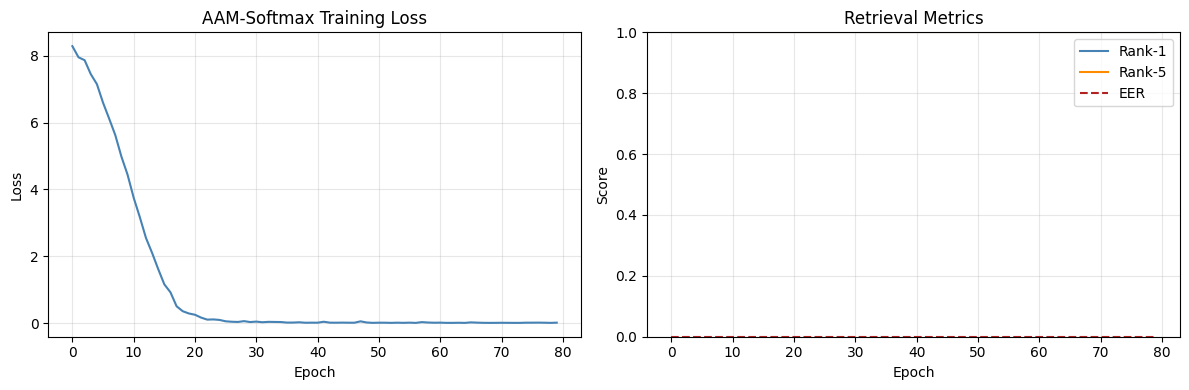

Final — R@1=1.000  R@5=1.000  EER=0.000  mAP=1.000


In [23]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history["loss"], color="steelblue")
axes[0].set(xlabel="Epoch", ylabel="Loss", title="AAM-Softmax Training Loss")
axes[0].grid(alpha=0.3)

axes[1].plot(history["rank1"], label="Rank-1", color="steelblue")
axes[1].plot(history["rank5"], label="Rank-5", color="darkorange")
axes[1].plot(history["eer"],   label="EER",    color="firebrick",  linestyle="--")
axes[1].set(xlabel="Epoch", ylabel="Score", title="Retrieval Metrics", ylim=(0, 1))
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(os.path.dirname(CHECKPOINT), "training_curves.png"), dpi=120)
plt.show()
print(f"Final — R@1={history['rank1'][-1]:.3f}  R@5={history['rank5'][-1]:.3f}  "
      f"EER={history['eer'][-1]:.3f}  mAP={history['map'][-1]:.3f}")


In [24]:
ckpt = torch.load(CHECKPOINT, map_location=DEVICE)
model.load_state_dict(ckpt["model"])

q_emb, q_lbl = encode_all(val_loader, model)
emb_np = q_emb.numpy()
lbl_np = q_lbl.numpy()

tsne   = TSNE(n_components=2, perplexity=15, random_state=42, max_iter=1000)
coords = tsne.fit_transform(emb_np)

colors = plt.cm.tab10(np.linspace(0, 1, NUM_CLASSES))
fig, ax = plt.subplots(figsize=(8, 6))
for ci, person in enumerate(all_persons):
    mask = lbl_np == ci
    ax.scatter(coords[mask, 0], coords[mask, 1],
               c=[colors[ci]], label=person, s=70, alpha=0.85, edgecolors="none")
ax.legend(fontsize=7, ncol=2, loc="best")
ax.set(xlabel="t-SNE 1", ylabel="t-SNE 2",
       title=f"t-SNE val embeddings — best model (Rank-1={ckpt['rank1']:.3f})")
plt.tight_layout()
plt.savefig(os.path.join(os.path.dirname(CHECKPOINT), "tsne.png"), dpi=120)
plt.show()

ValueError: perplexity (15) must be less than n_samples (1)

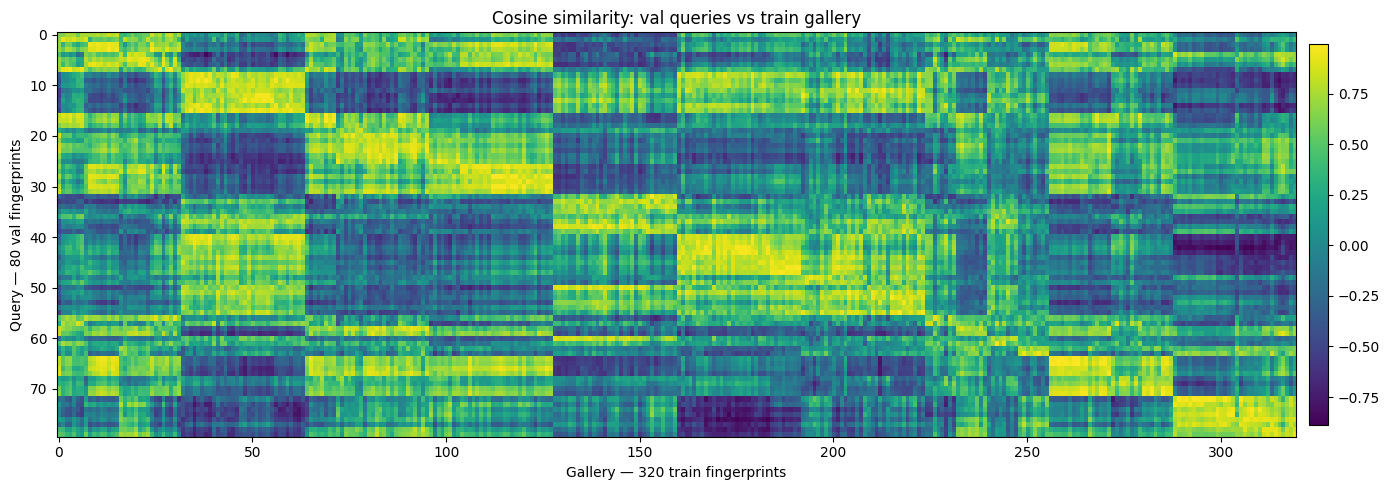

Similarity range  : [-0.8894, 0.9961]
Rank-1            : 0.850
Rank-5            : 0.913
EER               : 0.173
mAP               : 0.628


In [12]:
g_emb, g_lbl = encode_all(train_loader_eval, model)
q_emb, q_lbl = encode_all(val_loader,        model)
sim_matrix   = (q_emb @ g_emb.t()).numpy()   # (80, 320)

fig, ax = plt.subplots(figsize=(14, 5))
im = ax.imshow(sim_matrix, aspect="auto", cmap="viridis")
plt.colorbar(im, ax=ax, fraction=0.015, pad=0.01)
ax.set(xlabel="Gallery — 320 train fingerprints",
       ylabel="Query — 80 val fingerprints",
       title="Cosine similarity: val queries vs train gallery")
plt.tight_layout()
plt.savefig(os.path.join(os.path.dirname(CHECKPOINT), "sim_heatmap.png"), dpi=120)
plt.show()

print(f"Similarity range  : [{sim_matrix.min():.4f}, {sim_matrix.max():.4f}]")
print(f"Rank-1            : {rank_k(q_emb, q_lbl, g_emb, g_lbl, 1):.3f}")
print(f"Rank-5            : {rank_k(q_emb, q_lbl, g_emb, g_lbl, 5):.3f}")
print(f"EER               : {compute_eer(q_emb, q_lbl, g_emb, g_lbl):.3f}")
print(f"mAP               : {compute_map(q_emb, q_lbl, g_emb, g_lbl):.3f}")
